# Chicken Threat Detector Model v3

## Install dependencies


In [2]:
%pip install -q --no-cache-dir --force-reinstall --no-deps "Pillow==10.4.0"
%pip install -q --no-cache-dir --force-reinstall --no-deps "ultralytics==8.4.77" "ultralytics-thop==2.0.20"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 60.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


## Runtime setup

In [4]:
import os
import random
import shutil
import sys
import zipfile
from collections import Counter
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image
from tqdm.auto import tqdm

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in str(get_ipython())
USE_GOOGLE_DRIVE = False

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    os.environ.setdefault("CHICKEN_THREAT_WORKDIR", "/content/drive/MyDrive/chicken_threat_detector_v3_model")
elif IN_COLAB:
    os.environ.setdefault("CHICKEN_THREAT_WORKDIR", "/content/chicken_threat_detector_v3_model")

WORK_DIR = Path(os.getenv("CHICKEN_THREAT_WORKDIR", "data/chicken_threat_detector_v3_model")).resolve()
IMPORT_ROOT = WORK_DIR / "imported_dataset"
RUNS_ROOT = WORK_DIR / "runs"
EXPORT_ROOT = WORK_DIR / "exports"
for directory in (WORK_DIR, IMPORT_ROOT, RUNS_ROOT, EXPORT_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

SPLITS = ("train", "valid", "test")
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
CANONICAL_NAMES = [
    "chicken",
    "other_poultry",
    "rodent",
    "fox",
    "cat",
    "dog",
    "marten_weasel",
    "bird_of_prey",
    "other_bird",
    "person",
]

print(f"IN_COLAB={IN_COLAB}")
print(f"WORK_DIR={WORK_DIR}")


IN_COLAB=True
WORK_DIR=/content/chicken_threat_detector_v3_model


## Locate dataset input


In [5]:
DATASET_ZIP_PATH = None
KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_DATASET_SLUG = "chicken-threat-dataset-v3-zip"
KAGGLE_EXPORT_NAME = "chicken_threat_dataset_v3.zip"


def clean_dir(path: Path) -> None:
    path = path.resolve()
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def upload_zip_in_colab() -> Path:
    if not IN_COLAB:
        raise RuntimeError("Set DATASET_ZIP_PATH when running locally.")
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Upload exactly one dataset zip.")
    uploaded_name = next(iter(uploaded))
    return Path(uploaded_name).resolve()


def find_dataset_root(root: Path) -> Path:
    candidates = [root, *[path for path in root.rglob("data.yaml")]]
    for candidate in candidates:
        dataset_root = candidate.parent if candidate.name == "data.yaml" else candidate
        if (dataset_root / "data.yaml").exists():
            if all((dataset_root / split / "images").exists() for split in ("train", "valid")):
                return dataset_root.resolve()
    raise FileNotFoundError(f"Could not find a YOLO data.yaml with train/valid folders under {root}")


def write_runtime_data_yaml(dataset_root: Path) -> Path:
    source_yaml = dataset_root / "data.yaml"
    data = yaml.safe_load(source_yaml.read_text(encoding="utf-8")) or {}
    data["path"] = str(dataset_root.resolve())
    data.setdefault("train", "train/images")
    data.setdefault("val", "valid/images")
    data.setdefault("test", "test/images")
    data["nc"] = len(data.get("names", CANONICAL_NAMES))
    runtime_yaml = WORK_DIR / "data.yaml"
    runtime_yaml.write_text(yaml.safe_dump(data, sort_keys=False), encoding="utf-8")
    return runtime_yaml


def kaggle_dataset_candidates() -> list[Path]:
    if not KAGGLE_INPUT_ROOT.exists():
        return []
    dataset_root = KAGGLE_INPUT_ROOT / KAGGLE_DATASET_SLUG
    candidates = [dataset_root / KAGGLE_EXPORT_NAME, dataset_root]
    candidates.extend(KAGGLE_INPUT_ROOT.rglob(KAGGLE_EXPORT_NAME))
    candidates.extend(path.parent for path in KAGGLE_INPUT_ROOT.rglob("data.yaml"))
    return candidates


def resolve_dataset_source() -> Path:
    candidates = [Path(DATASET_ZIP_PATH).expanduser()] if DATASET_ZIP_PATH else kaggle_dataset_candidates()
    if not candidates and IN_COLAB:
        candidates = [upload_zip_in_colab()]
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.is_file() and candidate.suffix.lower() == ".zip":
            return candidate
        if candidate.is_dir():
            try:
                return find_dataset_root(candidate)
            except FileNotFoundError:
                pass
    raise FileNotFoundError(
        "Could not find chicken_threat_dataset_v3.zip or an extracted YOLO dataset under /kaggle/input. "
        "Check that the Kaggle input dataset chicken-threat-dataset-v3-zip is attached."
    )


dataset_source = resolve_dataset_source()
if dataset_source.is_file():
    clean_dir(IMPORT_ROOT)
    with zipfile.ZipFile(dataset_source) as archive:
        archive.extractall(IMPORT_ROOT)
    DATASET_ROOT = find_dataset_root(IMPORT_ROOT)
else:
    DATASET_ROOT = dataset_source

DATA_YAML = write_runtime_data_yaml(DATASET_ROOT)
print(f"Dataset source: {dataset_source}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"data.yaml: {DATA_YAML}")


Dataset source: /kaggle/input/datasets/dumdart/chicken-threat-dataset-v3-zip
Dataset root: /kaggle/input/datasets/dumdart/chicken-threat-dataset-v3-zip
data.yaml: /content/chicken_threat_detector_v3_model/data.yaml


## Dataset validation and class balance

In [7]:
def load_class_names(dataset_root: Path) -> list[str]:
    data = yaml.safe_load((dataset_root / "data.yaml").read_text(encoding="utf-8"))
    names = data.get("names")
    if isinstance(names, dict):
        return [str(names[key]) for key in sorted(names, key=lambda key: int(key))]
    if isinstance(names, list):
        return [str(name) for name in names]
    raise ValueError("data.yaml has unsupported names format")


def image_files(image_dir: Path) -> list[Path]:
    if not image_dir.exists():
        return []
    return sorted(path for path in image_dir.iterdir() if path.suffix.lower() in IMAGE_SUFFIXES)


def clip_yolo_box(box: Iterable[float]) -> tuple[float, float, float, float] | None:
    x_center, y_center, width, height = [float(value) for value in box]
    if width <= 0 or height <= 0:
        return None
    x_min = max(0.0, x_center - width / 2)
    y_min = max(0.0, y_center - height / 2)
    x_max = min(1.0, x_center + width / 2)
    y_max = min(1.0, y_center + height / 2)
    width = x_max - x_min
    height = y_max - y_min
    if width <= 0 or height <= 0:
        return None
    return ((x_min + x_max) / 2, (y_min + y_max) / 2, width, height)


def parse_yolo_line(line: str) -> tuple[int, tuple[float, float, float, float]] | None:
    parts = line.split()
    if len(parts) != 5:
        return None
    try:
        class_id = int(float(parts[0]))
        coords = [float(value) for value in parts[1:]]
    except ValueError:
        return None
    box = clip_yolo_box(coords)
    if box is None:
        return None
    return class_id, box


def summarize_dataset(dataset_root: Path) -> pd.DataFrame:
    names = load_class_names(dataset_root)
    rows = []
    for split in SPLITS:
        image_dir = dataset_root / split / "images"
        label_dir = dataset_root / split / "labels"
        counts = Counter()
        invalid = 0
        missing = 0
        empty = 0
        for image_path in image_files(image_dir):
            label_path = label_dir / f"{image_path.stem}.txt"
            if not label_path.exists():
                missing += 1
                continue
            text = label_path.read_text(encoding="utf-8").strip()
            if not text:
                empty += 1
                continue
            for line in text.splitlines():
                parsed = parse_yolo_line(line)
                if parsed is None:
                    invalid += 1
                    continue
                class_id, _ = parsed
                label = names[class_id] if 0 <= class_id < len(names) else f"unknown:{class_id}"
                counts[label] += 1
        for name in names:
            rows.append({"split": split, "class": name, "objects": counts[name]})
        rows.append({"split": split, "class": "__images__", "objects": len(image_files(image_dir))})
        rows.append({"split": split, "class": "__missing_label_files__", "objects": missing})
        rows.append({"split": split, "class": "__empty_label_files__", "objects": empty})
        rows.append({"split": split, "class": "__invalid_labels__", "objects": invalid})
    return pd.DataFrame(rows)


def validate_dataset(dataset_root: Path) -> list[str]:
    errors = []
    names = load_class_names(dataset_root)
    if names != CANONICAL_NAMES:
        errors.append(f"Class names differ from expected canonical names: {names}")
    for split in SPLITS:
        image_dir = dataset_root / split / "images"
        label_dir = dataset_root / split / "labels"
        if not image_dir.exists():
            errors.append(f"Missing image directory: {image_dir}")
        if not label_dir.exists():
            errors.append(f"Missing label directory: {label_dir}")
        image_stems = {path.stem for path in image_files(image_dir)}
        label_stems = {path.stem for path in label_dir.glob("*.txt")} if label_dir.exists() else set()
        if image_stems - label_stems:
            errors.append(f"{split}: {len(image_stems - label_stems)} missing label files")
        if label_stems - image_stems:
            errors.append(f"{split}: {len(label_stems - image_stems)} orphan label files")
        for label_path in sorted(label_dir.glob("*.txt")) if label_dir.exists() else []:
            for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
                if not line.strip():
                    continue
                parsed = parse_yolo_line(line)
                if parsed is None:
                    errors.append(f"{label_path}:{line_number}: invalid label row")
                    continue
                class_id, box = parsed
                if not 0 <= class_id < len(names):
                    errors.append(f"{label_path}:{line_number}: class id out of range")
                if any(value < 0 or value > 1 for value in box):
                    errors.append(f"{label_path}:{line_number}: box outside 0..1")
    return errors


summary_df = summarize_dataset(DATASET_ROOT)
display(summary_df.pivot(index="class", columns="split", values="objects").fillna(0).astype(int))

validation_errors = validate_dataset(DATASET_ROOT)
if validation_errors:
    print("Validation failed:")
    for error in validation_errors[:100]:
        print(" -", error)
    raise RuntimeError(f"Dataset validation failed with {len(validation_errors)} errors.")
print("Validation passed.")


split,test,train,valid
class,,,
__empty_label_files__,0,0,0
__images__,712,3919,659
__invalid_labels__,0,0,0
__missing_label_files__,0,0,0
bird_of_prey,100,600,86
cat,100,600,100
chicken,116,700,121
dog,101,601,100
fox,100,565,44


Validation passed.


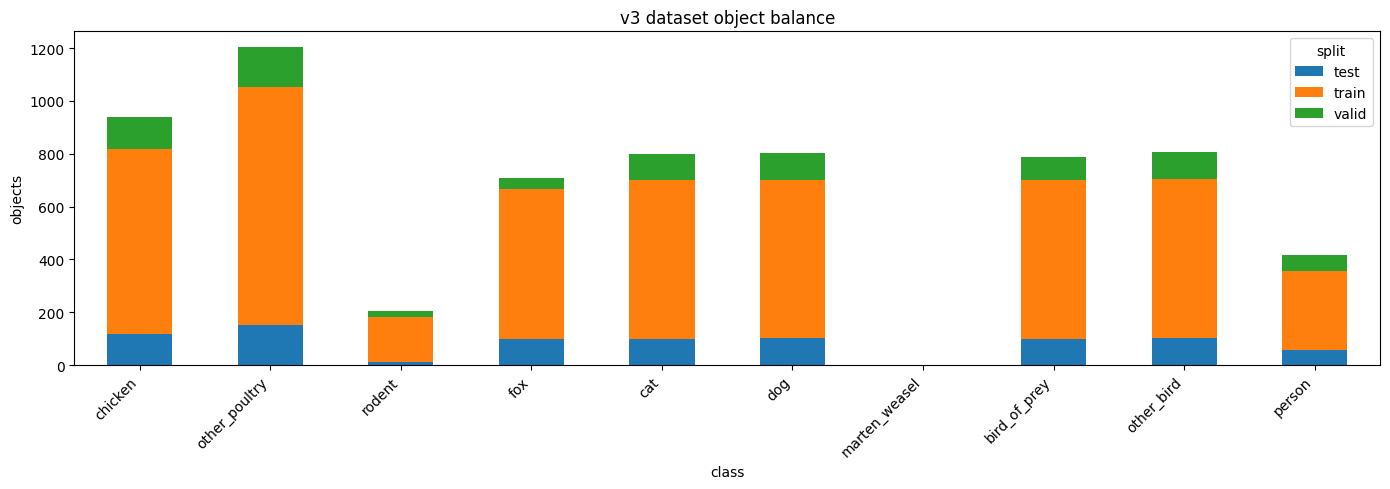

In [9]:
plot_df = summary_df[~summary_df["class"].str.startswith("__")]
pivot = plot_df.pivot(index="class", columns="split", values="objects").fillna(0)
pivot.loc[CANONICAL_NAMES].plot(kind="bar", stacked=True, figsize=(14, 5))
plt.title("v3 dataset object balance")
plt.ylabel("objects")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Training configuration

In [10]:
import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

MODEL_WEIGHTS = "yolo11s.pt"   # switch to yolo11n.pt for faster/cheaper experiments
RUN_NAME = "v3_yolo11s_aug_balanced"
EPOCHS = 150
IMG_SIZE = 640
PATIENCE = 30

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

TRAIN_ARGS = dict(
    data=str(DATA_YAML),
    model="yolo11s.pt",

    # Core training
    epochs=130,
    patience=20,
    imgsz=640,
    batch=32,
    device=[0, 1],
    workers=4,
    seed=42,
    deterministic=False,
    pretrained=True,
    amp=True,

    # Optimizer: lock what auto already selected
    optimizer="AdamW",
    lr0=0.0007,
    lrf=0.01,
    momentum=0.9,
    weight_decay=0.00055,
    cos_lr=True,
    warmup_epochs=3.0,

    # Loss balancing
    box=7.5,
    cls=0.65,
    dfl=1.5,

    # Augmentation: slightly less synthetic than current run
    hsv_h=0.015,
    hsv_s=0.55,
    hsv_v=0.30,
    degrees=5.0,
    translate=0.07,
    scale=0.40,
    shear=1.0,
    perspective=0.0003,
    fliplr=0.5,
    flipud=0.0,

    # Mosaic/mix augmentations
    mosaic=0.60,
    close_mosaic=20,
    mixup=0.05,
    copy_paste=0.03,
    copy_paste_mode="flip",

    # Validation/export behavior
    val=True,
    plots=False,
    save=True,
    save_period=-1,
    project=str(RUN_NAME),
    name="v3_1_yolo11s_stable",
    exist_ok=True,
)

TRAIN_ARGS


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
GPU: Tesla T4


{'data': '/content/chicken_threat_detector_v3_model/data.yaml',
 'model': 'yolo11s.pt',
 'epochs': 130,
 'patience': 20,
 'imgsz': 640,
 'batch': 32,
 'device': [0, 1],
 'workers': 4,
 'seed': 42,
 'deterministic': False,
 'pretrained': True,
 'amp': True,
 'optimizer': 'AdamW',
 'lr0': 0.0007,
 'lrf': 0.01,
 'momentum': 0.9,
 'weight_decay': 0.00055,
 'cos_lr': True,
 'warmup_epochs': 3.0,
 'box': 7.5,
 'cls': 0.65,
 'dfl': 1.5,
 'hsv_h': 0.015,
 'hsv_s': 0.55,
 'hsv_v': 0.3,
 'degrees': 5.0,
 'translate': 0.07,
 'scale': 0.4,
 'shear': 1.0,
 'perspective': 0.0003,
 'fliplr': 0.5,
 'flipud': 0.0,
 'mosaic': 0.6,
 'close_mosaic': 20,
 'mixup': 0.05,
 'copy_paste': 0.03,
 'copy_paste_mode': 'flip',
 'val': True,
 'plots': False,
 'save': True,
 'save_period': -1,
 'project': 'v3_yolo11s_aug_balanced',
 'name': 'v3_1_yolo11s_stable',
 'exist_ok': True}

## Train model

In [12]:
model = YOLO(MODEL_WEIGHTS)
results = model.train(**TRAIN_ARGS)

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.65, cls_pw=0.0, compile=False, conf=None, copy_paste=0.03, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/chicken_threat_detector_v3_model/data.yaml, degrees=5.0, deterministic=False, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=130, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.55, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0007, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11s.pt, momentum=0.9,

In [21]:
from pathlib import Path

# Robust Ultralytics save_dir handling
if hasattr(results, "save_dir"):
    RUN_DIR = Path(results.save_dir)
elif hasattr(model, "trainer") and hasattr(model.trainer, "save_dir"):
    RUN_DIR = Path(model.trainer.save_dir)
else:
    # Fallback: reconstruct from args
    RUN_DIR = Path(TRAIN_ARGS["project"]) / TRAIN_ARGS["name"]

BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS = RUN_DIR / "weights" / "last.pt"

print(f"Run directory: {RUN_DIR}")
print(f"Best weights: {BEST_WEIGHTS}")
print(f"Last weights: {LAST_WEIGHTS}")
print("Best exists:", BEST_WEIGHTS.exists())
print("Last exists:", LAST_WEIGHTS.exists())

NameError: name 'results' is not defined

In [15]:
from pathlib import Path
import shutil

RUN_DIR = Path("/kaggle/working/runs/detect/v3_yolo11s_aug_balanced/v3_1_yolo11s_stable")
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS = RUN_DIR / "weights" / "last.pt"

print("Best exists:", BEST_WEIGHTS.exists(), BEST_WEIGHTS)
print("Last exists:", LAST_WEIGHTS.exists(), LAST_WEIGHTS)

EXPORT_DIR = Path("/kaggle/working/chicken_threat_model_v3_1_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy2(BEST_WEIGHTS, EXPORT_DIR / "best.pt")
shutil.copy2(LAST_WEIGHTS, EXPORT_DIR / "last.pt")

# Copy useful training files if they exist
for filename in ["args.yaml", "results.csv", "confusion_matrix.png", "results.png"]:
    src = RUN_DIR / filename
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / filename)

# Copy dataset yaml
if Path(DATA_YAML).exists():
    shutil.copy2(DATA_YAML, EXPORT_DIR / "data.yaml")

zip_path = shutil.make_archive(
    "/kaggle/working/chicken_threat_model_v3_1_export",
    "zip",
    root_dir=EXPORT_DIR,
)

print("Exported:", zip_path)
print("Size MB:", Path(zip_path).stat().st_size / 1024 / 1024)

Best exists: True /kaggle/working/runs/detect/v3_yolo11s_aug_balanced/v3_1_yolo11s_stable/weights/best.pt
Last exists: True /kaggle/working/runs/detect/v3_yolo11s_aug_balanced/v3_1_yolo11s_stable/weights/last.pt
Exported: /kaggle/working/chicken_threat_model_v3_1_export.zip
Size MB: 33.575194358825684


## Evaluate validation and test performance

In [16]:
def evaluate_split(weights_path: Path, split: str):
    eval_model = YOLO(str(weights_path))
    metrics = eval_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=IMG_SIZE,
        project=str(RUNS_ROOT),
        name=f"{RUN_NAME}_eval_{split}",
        plots=False,      # important for now
        conf=0.001,
        iou=0.6,
        batch=32,
        device=0,
    )

    print(f"\n{split.upper()} metrics")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"mAP50:    {metrics.box.map50:.4f}")
    print(f"mAP75:    {metrics.box.map75:.4f}")
    return metrics

if not BEST_WEIGHTS.exists() and LAST_WEIGHTS.exists(): 
    BEST_WEIGHTS = LAST_WEIGHTS 
if not BEST_WEIGHTS.exists(): 
    raise FileNotFoundError("No trained weights found. Run training first.") 
    
valid_metrics = evaluate_split(BEST_WEIGHTS, "val") 
test_metrics = evaluate_split(BEST_WEIGHTS, "test")

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±1.0 ms, read: 11.0±5.4 MB/s, size: 240.2 KB)
val: Scanning /kaggle/input/datasets/dumdart/chicken-threat-dataset-v3-zip/valid/labels... 659 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 659/659 194.1it/s 3.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/dumdart/chicken-threat-dataset-v3-zip/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 2.8it/s 7.5s0.3s
                   all        659        784      0.829       0.75      0.796      0.643
               chicken         59        121      0.874      0.628      0.748      0.561
         other_poultry        116        150      0.818      0.853      0.879       0.69
                rodent         21         23   

In [17]:
def per_class_map_table(metrics, split_name: str) -> pd.DataFrame:
    names = metrics.names if hasattr(metrics, "names") else {i: name for i, name in enumerate(CANONICAL_NAMES)}
    maps = getattr(metrics.box, "maps", [])
    rows = []
    for i, value in enumerate(maps):
        rows.append({"split": split_name, "class": names.get(i, str(i)) if isinstance(names, dict) else names[i], "mAP50-95": float(value)})
    return pd.DataFrame(rows)

per_class_df = pd.concat([
    per_class_map_table(valid_metrics, "valid"),
    per_class_map_table(test_metrics, "test"),
], ignore_index=True)
display(per_class_df.pivot(index="class", columns="split", values="mAP50-95").loc[CANONICAL_NAMES])


split,test,valid
class,,
chicken,0.604421,0.561138
other_poultry,0.548312,0.690486
rodent,0.367464,0.684791
fox,0.819033,0.827483
cat,0.753630,0.828712
dog,0.779299,0.789956
marten_weasel,0.574068,0.643228
bird_of_prey,0.808419,0.808085
other_bird,0.413440,0.456916


## Inspect evaluation plots

In [18]:
def show_image_if_exists(path: Path, title: str) -> None:
    if path.exists():
        image = Image.open(path)
        plt.figure(figsize=(9, 7))
        plt.imshow(image)
        plt.axis("off")
        plt.title(title)
        plt.show()
    else:
        print(f"Not found: {path}")

show_image_if_exists(RUNS_ROOT / f"{RUN_NAME}_eval_test" / "confusion_matrix.png", "Test confusion matrix")
show_image_if_exists(RUNS_ROOT / f"{RUN_NAME}_eval_test" / "PR_curve.png", "Test PR curve")


Not found: /content/chicken_threat_detector_v3_model/runs/v3_yolo11s_aug_balanced_eval_test/confusion_matrix.png
Not found: /content/chicken_threat_detector_v3_model/runs/v3_yolo11s_aug_balanced_eval_test/PR_curve.png


## Export best model package

In [19]:
MODEL_EXPORT_DIR = EXPORT_ROOT / RUN_NAME
MODEL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for source in [BEST_WEIGHTS, LAST_WEIGHTS, DATA_YAML, RUN_DIR / "args.yaml", RUN_DIR / "results.csv"]:
    if Path(source).exists():
        shutil.copy2(source, MODEL_EXPORT_DIR / Path(source).name)

# Also save a compact metrics summary.
metrics_summary = {
    "model_weights": MODEL_WEIGHTS,
    "run_name": RUN_NAME,
    "best_weights": str(BEST_WEIGHTS),
    "valid_map50_95": float(valid_metrics.box.map),
    "valid_map50": float(valid_metrics.box.map50),
    "test_map50_95": float(test_metrics.box.map),
    "test_map50": float(test_metrics.box.map50),
    "class_names": CANONICAL_NAMES,
}
(MODEL_EXPORT_DIR / "metrics_summary_v3.yaml").write_text(yaml.safe_dump(metrics_summary, sort_keys=False), encoding="utf-8")

zip_file = Path(shutil.make_archive(str(EXPORT_ROOT / RUN_NAME), "zip", root_dir=MODEL_EXPORT_DIR))
print(f"Model package: {zip_file}")
print(f"Size: {zip_file.stat().st_size / (1024 * 1024):.1f} MB")

if IN_COLAB:
    from google.colab import files
    files.download(str(zip_file))
else:
    print(zip_file)


Model package: /content/chicken_threat_detector_v3_model/exports/v3_yolo11s_aug_balanced.zip
Size: 33.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference sanity check on random test images


0: 640x640 6 other_poultrys, 3 other_birds, 12.4ms
1: 640x640 1 bird_of_prey, 12.4ms
2: 640x640 1 bird_of_prey, 12.4ms
3: 640x640 (no detections), 12.4ms
4: 640x640 (no detections), 12.4ms
5: 640x640 1 cat, 12.4ms
Speed: 2.8ms preprocess, 12.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


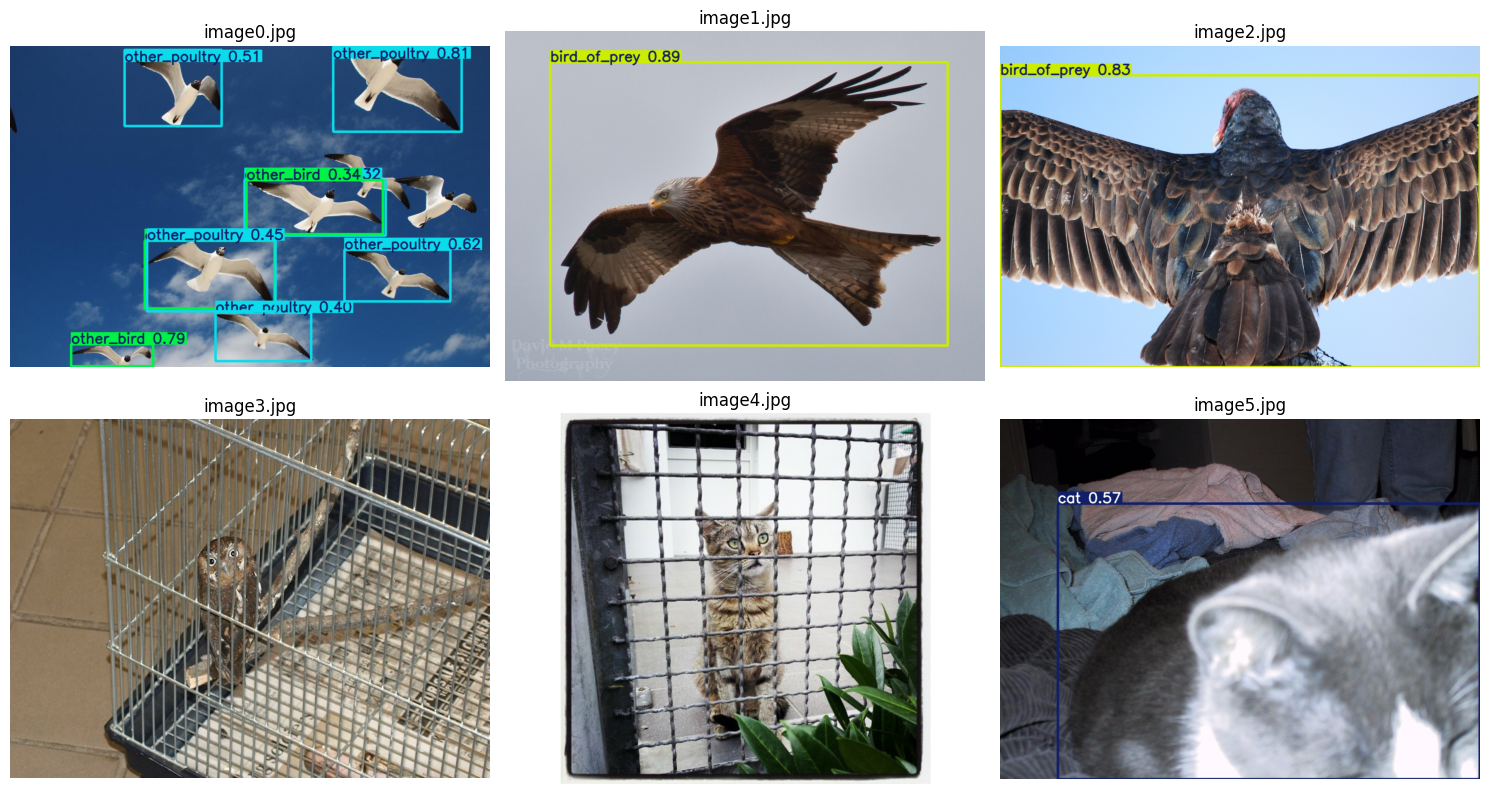

In [20]:
sample_dir = DATASET_ROOT / "test" / "images"
sample_images = image_files(sample_dir)
if not sample_images:
    print("No test images found.")
else:
    selected = random.sample(sample_images, k=min(6, len(sample_images)))
    inference_model = YOLO(str(BEST_WEIGHTS))
    predictions = inference_model.predict(source=[str(path) for path in selected], conf=0.25, imgsz=IMG_SIZE)

    columns = 3
    rows = (len(predictions) + columns - 1) // columns
    plt.figure(figsize=(5 * columns, 4 * rows))
    for index, result in enumerate(predictions, start=1):
        rendered = result.plot()[..., ::-1]
        plt.subplot(rows, columns, index)
        plt.imshow(rendered)
        plt.axis("off")
        plt.title(Path(result.path).name[:35])
    plt.tight_layout()
    plt.show()
